In [1]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

In [2]:
from typing import List, Optional
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
import warnings
warnings.filterwarnings("ignore")
import math
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


from qiskit_aer import AerSimulator
backend =  AerSimulator(method='statevector')

# Sesión 4 Laboratorio de Computación Cuántica 2

## Algoritmo de Bernstein Vazirani

El Algoritmo de Bernstein Vazirani es un algoritmo que permite resolver un problema usando una sola iteración de un oráculo, en lugar de multiples veces de revisar. Es parecido a Deutsch-Jozsa, solo que el oráculo que utiliza es levemente diferente

Para explicar el problema, hay que entender una operación de strings. Sea x un string de 0s y 1s y s otro string similar, como $x = 1000$ and $s = 1010$, entonces, el producto escalar módulo 2 se vuelve $x\cdot s = 1.1 + 0.0 + 0.1 + 0.0 = 1 \pmod 2 = 1$

Con esto en mente, el problema que Bernstein Vazirani busca resolver es el siguiente:

Te dan una función $f:\{0,1\}^n \rightarrow \{0,1\}$, tal que $ f(\mathbf{x}) = x \cdot s$ para algún s arbitrario, donde s es un string de 0 y 1. Entonces, tu misión es encontrar $s$.

### Ejercicio 1 para puntos extra en la próxima práctica de laboratorio (en clase):

¿Cuantas veces necesitas ejecutar f(x) y por que para identificar el valor de s? (Hint, intenta aplicar f(x) a los strings 1000, 0100, 0010, 0001)

Respuesta:


Si s es un string de longitud n, debes evaluar f(x) un total de n veces, para los valores de x donde $x_i=0$ si $i\neq j$ o $x_i=1$ si $i=j$

### Recordatorio: Oráculo cuántico

En mecánica cuántica, la operación que aplique debe ser una compuerta unitaria, es decir:

$$
U^\dagger U = I
$$

Esto implica que la compuerta tiene que ser reversible. Sin embargo, en general, una función clásica $f$ no es reversible.

### Solución: Oráculo reversible

Creamos un oráculo reversible $U_f$ tal que:

$$
U_f |x\rangle |y\rangle \longrightarrow |x\rangle |y \oplus f(x)\rangle
$$

Donde $\oplus$ equivale a una suma bit a bit, es decir, la operación XOR.

Ejemplo:

$$
|101\rangle \oplus |011\rangle = |110\rangle
$$

Es decir, suma entrada por entrada en binario, equivalente a aplicar una compuerta XOR bit a bit.



El funcionamiento del algoritmo depende a partir de ahora de la implementación del Oráculo. Y en esta ocasión lo vamos a aplicar al circuito que ya conocemos de Deutsch Jozsa



### Circuito cuántico de Bernstein Vazirani




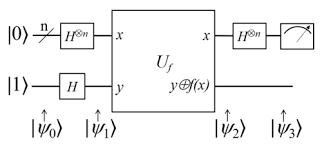




El circuito cuántico que vamos a aplicar resulta ser exactamente el mismo que el del circuito de Deutsch-Jozsa. Lo unico que cambia es la aplicación del oráculo del sistema. Veamos matemáticamente que esperamos medir aqui

$$
|\psi_0\rangle
=
|0\rangle^{\otimes n} \otimes |1\rangle
$$

$$
|\psi_1\rangle
=
\frac{1}{\sqrt{2^n}}\sum_{x \in \{0,1\}^n}|x\rangle\otimes|-\rangle.
$$

Aplicando el oráculo y el Phase kickback e ignorando el segundo sistema

$$
|\psi_2\rangle
=
\frac{1}{\sqrt{2^n}}\sum_{x \in \{0,1\}^n}(-1)^{x \cdot s}|x\rangle.
$$


Recordamos la identidad fundamental:

$$
H^{\otimes n} \ket{x}
=
\frac{1}{\sqrt{2^n}}
\sum_{z}
(-1)^{x \cdot z}
\ket{z}.
$$



Y dado que sabemos que la Hadamard es su propia inversa, entonces la aplicación del conjunto de Hadamards resulta en ser la inversa de este sistema, de modo que es completamente sensato decir que, con la ayuda de la identidad anterior

$$
|\psi_3\rangle
=
H^{\otimes n} |\psi_2\rangle
=
H^{\otimes n} \frac{1}{\sqrt{2^n}}\sum_{x \in \{0,1\}^n}(-1)^{x \cdot s}|x\rangle
=
|s\rangle
$$

Entonces, el primer estado resulta ser, precisamente el conjunto de strings que estamos buscando. Y con una sola iteración del algoritmo, hemos terminado

Actividad 1 Tarea: Demostrar la identidad de las matrices Hadamards

$$
H^{\otimes n} |x\rangle
=
\frac{1}{\sqrt{2^n}}\sum_{z \in \{0,1\}^n}(-1)^{x \cdot z}|z\rangle.
$$

Hint: Utiliza la inducción matemática

Actividad 2 Tarea: Usando la fórmula anterior, explicarme en tus propias palabras como aplicar n compuertas hadamard a los primeros n qubits nos recupera el ket s

Ahora, aquí va la pregunta interesante. ¿Tienes alguna idea de como fabricar el oráculo que corresponde a B-V?

In [3]:
s='10101'  
enumerate(s)

for i, bit in enumerate(s):
    print(f"Índice: {i}, Bit: {bit}")

Índice: 0, Bit: 1
Índice: 1, Bit: 0
Índice: 2, Bit: 1
Índice: 3, Bit: 0
Índice: 4, Bit: 1


In [4]:
from qiskit import QuantumCircuit

def bv_oracle(n, s):
    

    qc = QuantumCircuit(n)


    for i, bit in enumerate(s):
        if bit == '1':
            qc.cx(i, n-1)

    qc.barrier()

    return qc

In [5]:
def circ_init(n):
  qc = QuantumCircuit(n)
  for qubit in range(n-1):
    qc.h(qubit)
  return qc

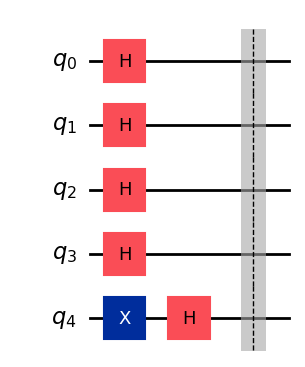

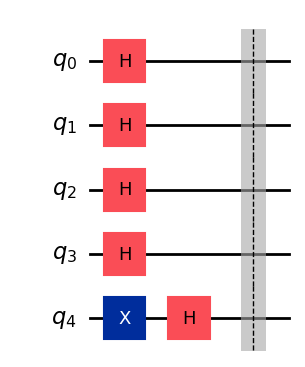

In [6]:
n=5

bv_circuit = circ_init(n)   #Iniciamos el circuito con Hadamards en el registro inicial
bv_circuit.x(n-1)           #El último qubit lo convertimos en estado |1>
bv_circuit.h(n-1)           #También aplicamos Hadamard aquí
bv_circuit.barrier()
bv_circuit.draw('mpl')

Aquí realizamos la superposición del inicio del algoritmo.

Para ello, aplicamos nuestro oráculo de B-V en el sistema con la función compose. Puedes jugar con el B-V

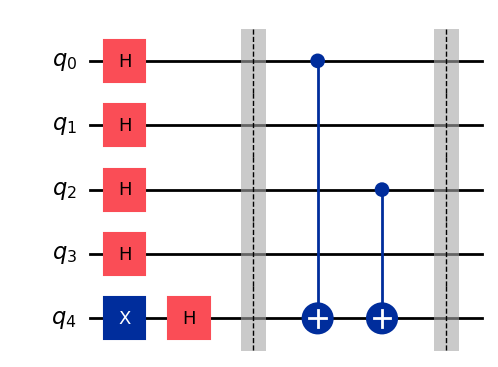

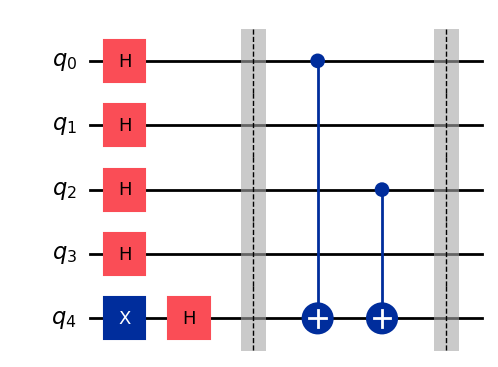

In [7]:
s='1010'  #Cadena de bits del algoritmo bv

bv_circuit = bv_circuit.compose(bv_oracle(n, s))
bv_circuit.draw('mpl')

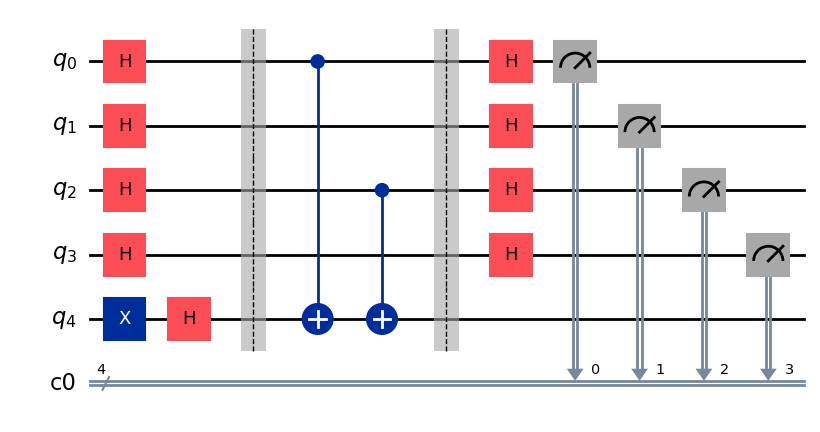

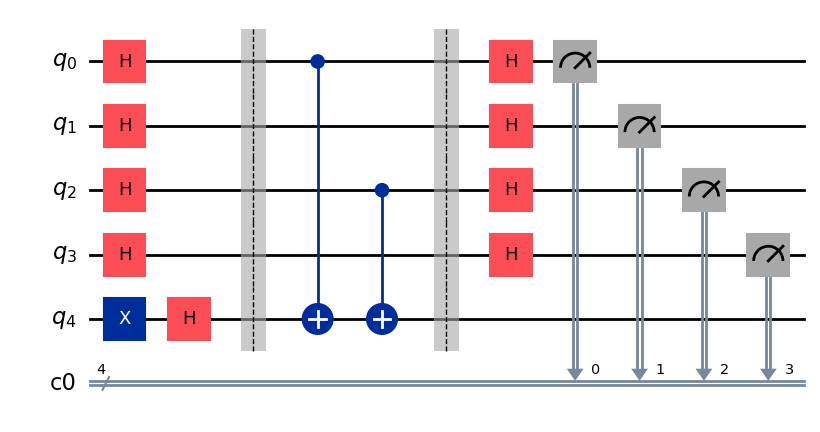

In [8]:
bv_circuit = bv_circuit.compose(circ_init(n))

bv_circuit.add_register(ClassicalRegister(n-1))

for qubit in range(n-1):
  bv_circuit.measure(qubit,qubit)
bv_circuit.draw('mpl')

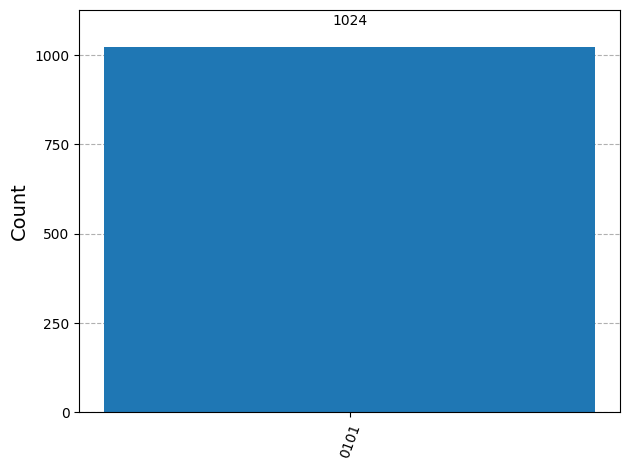

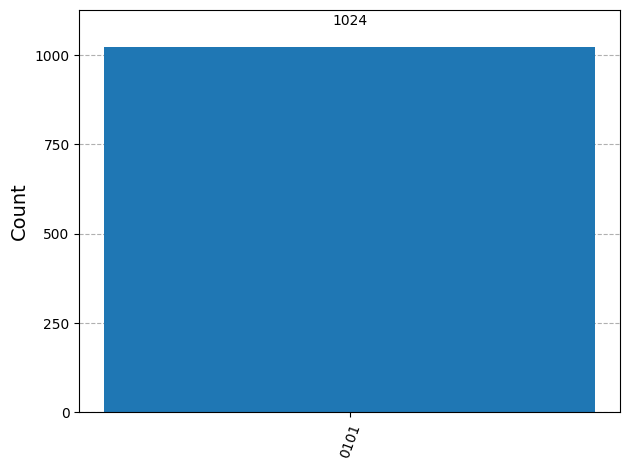

In [9]:
shots = 1024
counts = backend.run(bv_circuit, shots=shots).result().get_counts()
plot_histogram(counts)

Actividad 2 Tarea (Opcional)

¿Puedes replicar el mismo algoritmo en Pennylane? ¿Que necesitarias para hacerlo? Implementa V B en Pennylane